In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bioframe as bf

In [2]:
path = "/project2/fudenber_735/motifs/mm10/jaspar/MA0139.1.tsv.gz"

In [3]:
# load jaspar CTCF motifs
jaspar_df = bf.read_table(path, schema="jaspar", skiprows=1)

In [4]:
df_sorted = jaspar_df.sort_values(["chrom", "start"]).reset_index(drop=True)

In [5]:
distances = []

for chrom, group in df_sorted.groupby("chrom"):
    starts = group["start"].values
    ends = group["end"].values
    # distance to next motif: start_next - end_current
    chrom_dist = starts[1:] - ends[:-1]
    distances.extend(chrom_dist)

distances = np.array(distances)
print(f"Computed distances for {len(distances)} intervals")
print(f"min: {distances.min()}, median: {np.median(distances)}, max: {distances.max()}")

Computed distances for 825487 intervals
min: -18, median: 1902.0, max: 651978


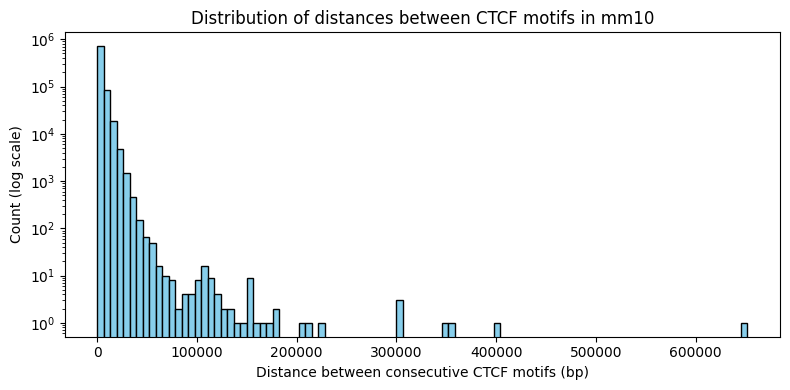

In [6]:
plt.figure(figsize=(8,4))
plt.hist(distances, bins=100, color='skyblue', edgecolor='k', log=True)  # log scale y for better visualization
plt.xlabel("Distance between consecutive CTCF motifs (bp)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of distances between CTCF motifs in mm10")
plt.tight_layout()
plt.show()

### CTCFs with distances < 300bp

In [7]:
close_pairs = []  # will store (index1, index2, chrom, distance)

for chrom, group in df_sorted.groupby("chrom"):
    idx = group.index.values
    starts = group["start"].values
    ends = group["end"].values

    # distances to next motif
    chrom_dist = starts[1:] - ends[:-1]

    # find those < 300 bp
    mask = chrom_dist < 300

    for i, is_close in enumerate(mask):
        if is_close:
            close_pairs.append({
                "chrom": chrom,
                "idx1": idx[i],       # first motif
                "idx2": idx[i+1],     # second motif
                "start1": group.loc[idx[i], "start"],
                "end1": group.loc[idx[i], "end"],
                "strand1": group.loc[idx[i], "strand"],
                "start2": group.loc[idx[i+1], "start"],
                "end2": group.loc[idx[i+1], "end"],
                "strand2": group.loc[idx[i+1], "strand"],
                "distance": chrom_dist[i]
            })

In [8]:
df_close = pd.DataFrame(close_pairs)

In [9]:
df_close

,chrom,idx1,idx2,start1,end1,strand1,start2,end2,strand2,distance
0,chr1,15,16,3071559,3071578,-,3071849,3071868,-,271
1,chr1,36,37,3150029,3150048,-,3150267,3150286,+,219
2,chr1,37,38,3150267,3150286,+,3150322,3150341,+,36
3,chr1,70,71,3325417,3325436,-,3325420,3325439,-,-16
4,chr1,81,82,3344834,3344853,+,3345045,3345064,+,192
...,...,...,...,...,...,...,...,...,...,...
113283,chrY,825501,825502,90828912,90828931,-,90828914,90828933,+,-17
113284,chrY,825502,825503,90828914,90828933,+,90829175,90829194,-,242
113285,chrY,825503,825504,90829175,90829194,-,90829177,90829196,+,-17
113286,chrY,825505,825506,90839573,90839592,+,90839785,90839804,-,193


In [10]:
clusters = []   # each cluster will be a list of row indices from df_sorted

for chrom, group in df_sorted.groupby("chrom"):
    idxs = group.index.to_list()
    starts = group["start"].values
    ends = group["end"].values
    
    current_cluster = [idxs[0]]
    
    for i in range(1, len(group)):
        dist = starts[i] - ends[i-1]
        
        if dist < 300:
            # same cluster
            current_cluster.append(idxs[i])
        else:
            # break cluster
            clusters.append(current_cluster)
            current_cluster = [idxs[i]]
    
    clusters.append(current_cluster)

In [12]:
valid_clusters = []

for cl in clusters:
    if len(cl) >= 3:     # at least 4 motifs
        # compute span
        cluster_starts = df_sorted.loc[cl, "start"]
        cluster_ends = df_sorted.loc[cl, "end"]
        span = cluster_ends.max() - cluster_starts.min()
        
        if span <= 10_000:   # within 10 kb
            valid_clusters.append({
                "motif_indices": cl,
                "chrom": df_sorted.loc[cl[0], "chrom"],
                "start": cluster_starts.min(),
                "end": cluster_ends.max(),
                "n_motifs": len(cl),
                "span": span
            })

In [13]:
cluster_df = pd.DataFrame(valid_clusters)

In [14]:
cluster_df

,motif_indices,chrom,start,end,n_motifs,span
0,"[36, 37, 38]",chr1,3150029,3150341,3,312
1,"[95, 96, 97]",chr1,3440397,3440569,3,172
2,"[198, 199, 200]",chr1,3929705,3930043,3,338
3,"[244, 245, 246]",chr1,4150704,4151008,3,304
4,"[353, 354, 355]",chr1,4592006,4592351,3,345
...,...,...,...,...,...,...
14679,"[825399, 825400, 825401, 825402]",chrY,90761430,90761718,4,288
14680,"[825408, 825409, 825410]",chrY,90772400,90772718,3,318
14681,"[825412, 825413, 825414, 825415, 825416, 82541...",chrY,90786076,90791994,69,5918
14682,"[825501, 825502, 825503, 825504]",chrY,90828912,90829196,4,284
